In [1]:
"""Importing all needed libraries"""
import os
import warnings
import numpy as np
import pandas as pd
from sklearn import tree
import seaborn as sns
from sklearn.svm import SVC
warnings.simplefilter('ignore')
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB,BernoulliNB
from imblearn.over_sampling import RandomOverSampler,SMOTE,ADASYN
from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler,PolynomialFeatures,LabelEncoder,StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis,QuadraticDiscriminantAnalysis
from sklearn.model_selection import train_test_split,StratifiedKFold,cross_val_score,GridSearchCV,KFold
from sklearn.metrics import roc_auc_score,log_loss,accuracy_score,mean_absolute_error,r2_score,mean_squared_error
from sklearn.linear_model import LogisticRegression,SGDClassifier,SGDRegressor,LinearRegression,Ridge,Lasso,ElasticNet
from sklearn.ensemble import VotingClassifier,VotingRegressor,BaggingClassifier,BaggingRegressor,RandomForestClassifier,RandomForestRegressor


# Table Of Content


1.	Data Preprocessing
2.	Data Manipulation
3.	Data Visiuilization
4.	Prediction
    * K-Nearest Neighbor
    * Naive Bayes
    * Logistic Regression
    * Support Vector Machine
    * Gradient Descent
    * Discriminant Analysis
    * Decision Tree
    * Random Forest
5.	Testing
6.	Submission



In [2]:
"""Importing train dataset"""
df=pd.read_csv("../input/titanic/train.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


# Data Preprocessing

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.shape

(891, 12)

In [5]:
"""Drop unnecessary columns"""
df.drop("Cabin",axis=1,inplace=True)

In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         2
dtype: int64


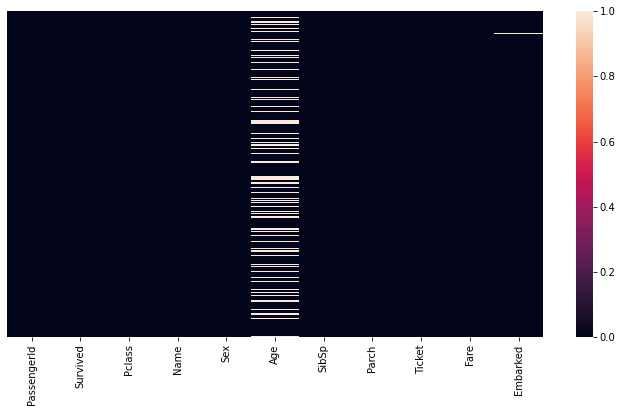

In [7]:
"""plot which shows columns having null values"""
print(df.isna().sum())
plt.figure(figsize=(12,6))
sns.heatmap(df.isna(),yticklabels=False)
plt.show()

# Data Manipulation

In [8]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         2
dtype: int64

In [9]:
df['Pclass'].unique()

array([3, 1, 2])

In [10]:
"""Avergae age acording to class"""
age=df.groupby('Pclass')['Age'].mean()
age.head()

Pclass
1    38.233441
2    29.877630
3    25.140620
Name: Age, dtype: float64

In [11]:
"""Fill NA values in age columns according to Pclass mean value"""
def AgeImputation(value):
    age = value[0]
    pclass = value[1]
    
    if np.isnan(age):
        if pclass == 1:
            return 38.23
        elif pclass == 2:
            return 29.87
        else:
            return 25.14
        
    else:
        return age
        
df["Age"] = df[["Age","Pclass"]].apply(AgeImputation,axis=1)

In [12]:
df['Embarked'].fillna(method='ffill',inplace=True)

In [13]:
"""Top 10 pasangers having Highest Fair"""
df.sort_values('Fare',ascending=False)[["PassengerId","Name","Sex","Fare","Survived"]][:10]

,PassengerId,Name,Sex,Fare,Survived
258,259,"Ward, Miss. Anna",female,512.3292,1
737,738,"Lesurer, Mr. Gustave J",male,512.3292,1
679,680,"Cardeza, Mr. Thomas Drake Martinez",male,512.3292,1
88,89,"Fortune, Miss. Mabel Helen",female,263.0000,1
27,28,"Fortune, Mr. Charles Alexander",male,263.0000,0
341,342,"Fortune, Miss. Alice Elizabeth",female,263.0000,1
438,439,"Fortune, Mr. Mark",male,263.0000,0
311,312,"Ryerson, Miss. Emily Borie",female,262.3750,1
742,743,"Ryerson, Miss. Susan Parker ""Suzette""",female,262.3750,1
118,119,"Baxter, Mr. Quigg Edmond",male,247.5208,0


**Observation**
<br>
Out of 20 total 14 Passengers are Survived with Highest Fair.
<br>
Females used to pay high fare in compare to Males.

# Data Visiulization

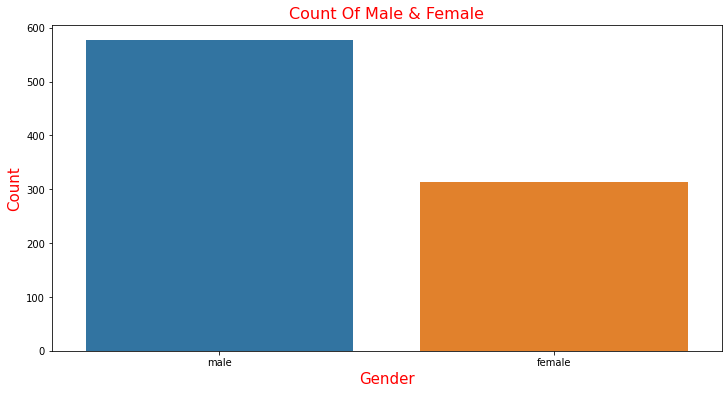

male      577
female    314
Name: Sex, dtype: int64


In [14]:
"""Count of Male and Female on titanic"""
plt.figure(figsize=(12,6))
sns.countplot(x='Sex',data=df)
plt.title("Count Of Male & Female",fontsize=16,color='red')
plt.xlabel("Gender",fontsize=15,color='red')
plt.ylabel("Count",fontsize=15,color='red')
plt.show()
print(df["Sex"].value_counts())

We can clearly see Males are more than Females in data.

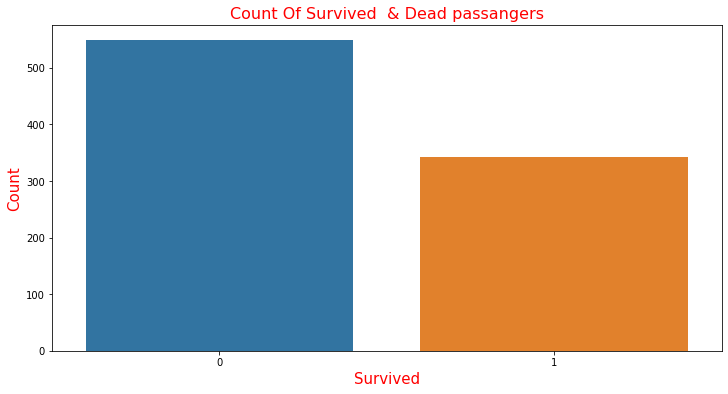

0    549
1    342
Name: Survived, dtype: int64


In [15]:
"""Count of passengers survived"""
plt.figure(figsize=(12,6))
sns.countplot(x='Survived',data=df)
plt.title("Count Of Survived  & Dead passangers",fontsize=16,color='red')
plt.xlabel("Survived",fontsize=15,color='red')
plt.ylabel("Count",fontsize=15,color='red')
plt.show()
print(df["Survived"].value_counts())

There is only 342 Passengers are Survived out of 891.

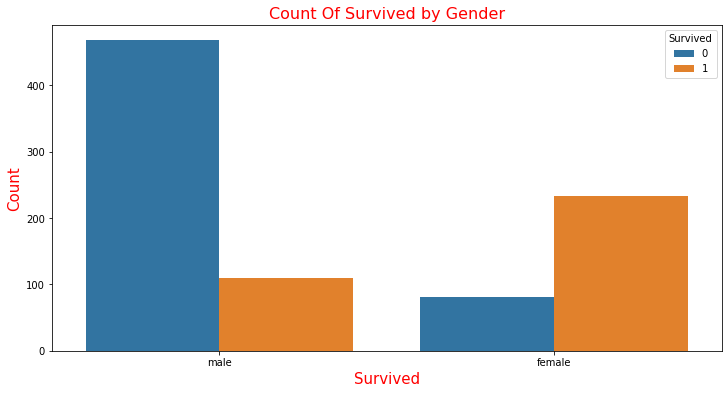

In [16]:
"""Count of male and females survived"""
plt.figure(figsize=(12,6))
sns.countplot(x='Sex',data=df,hue='Survived')
plt.title("Count Of Survived by Gender",fontsize=16,color='red')
plt.xlabel("Survived",fontsize=15,color='red')
plt.ylabel("Count",fontsize=15,color='red')
plt.show()

**Observation**
<br>
Survived Rate of Female is Very High in Compare to Male.

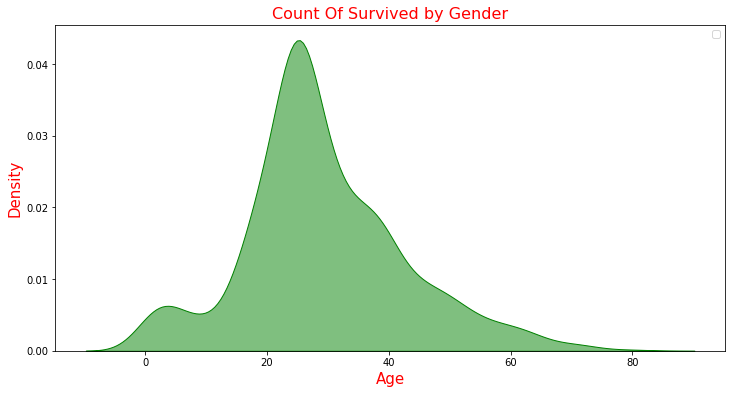

In [17]:
"""Age distributation plot"""
plt.figure(figsize=(12,6))
sns.kdeplot(x='Age',data=df,color='green',shade=True,alpha=0.5)
plt.title("Count Of Survived by Gender",fontsize=16,color='red')
plt.xlabel("Age",color='red',fontsize=15)
plt.ylabel("Density",color='red',fontsize=15)
plt.legend()
plt.show()


**Observation**
<br>
Most of the people's age is between 20-40. So, Most of the people were young.
<br>
There is very few people whose age is between 60-80.

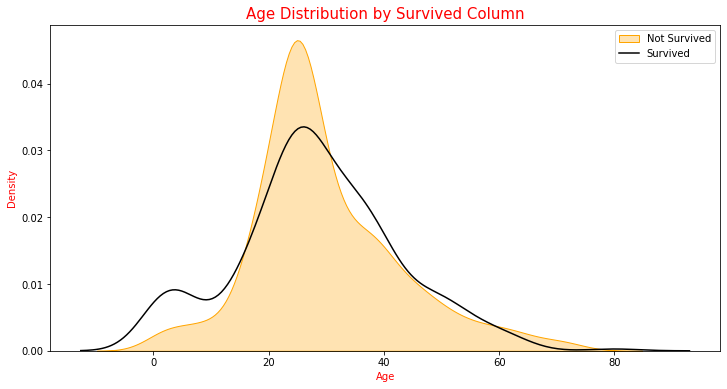

In [18]:
""" Age Distribution by Survived Column"""
plt.figure(figsize=(12,6))
sns.kdeplot(x="Age",data=df[df['Survived']==0].dropna(),shade=True,alpha=0.3,color="orange",label="Not Survived")
sns.kdeplot(x="Age",data=df[df['Survived']==1].dropna(),alpha=1,color="black",label="Survived")
plt.title("Age Distribution by Survived Column",size=15,color='red')
plt.xlabel("Age",color='red')
plt.ylabel("Density",color='red')
plt.legend()
plt.show()

**Observation**
<br>
If your age is between 0-10 (Child) then there is high chance that you survive.
<br>
If your age is between 60-80 (Elder) then there is high chance that you not survive.

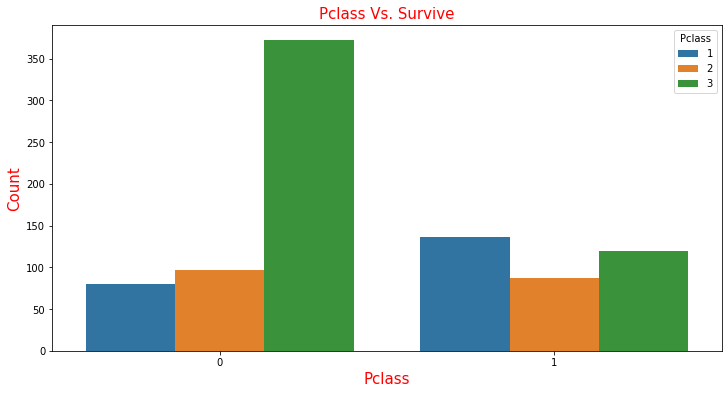

In [19]:
"""SUrvived and deaths according to Pclass"""
plt.figure(figsize=(12,6))
sns.countplot(x="Survived",data=df,hue="Pclass")
plt.title("Pclass Vs. Survive",size=15,color='red')
plt.xlabel("Pclass",color='red',size=15)
plt.ylabel("Count",color='red',size=15)
plt.show()

**Observation**
<br>
Most of the Passengers from Class 3 weren't Survived.
<br>
Most if the Passengers from Class 1 Survived.

# Predicition

## Getting response variable and responive variables

In [20]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [21]:
df.drop(columns=["PassengerId","Name","Ticket"],inplace=True)

In [22]:
dum=pd.get_dummies(df,drop_first=True)
dum

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.00,1,0,7.2500,1,0,1
1,1,1,38.00,1,0,71.2833,0,0,0
2,1,3,26.00,0,0,7.9250,0,0,1
3,1,1,35.00,1,0,53.1000,0,0,1
4,0,3,35.00,0,0,8.0500,1,0,1
...,...,...,...,...,...,...,...,...,...
886,0,2,27.00,0,0,13.0000,1,0,1
887,1,1,19.00,0,0,30.0000,0,0,1
888,0,3,25.14,1,2,23.4500,0,0,1
889,1,1,26.00,0,0,30.0000,1,0,0


In [23]:
X=dum.drop('Survived',axis=1)
y=dum['Survived']

## KNN Classification

In [24]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=2022,stratify=y)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(623, 8)
(268, 8)
(623,)
(268,)


In [25]:
for i in range(1,30,2):
    print(f"k={i}")
    knn=KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train,y_train)
    y_pred_prob=knn.predict_proba(X_test)[:,1]
    
    y_pred=knn.predict(X_test)
    print(accuracy_score(y_test, y_pred))
#this tells us we get best value of k=17

k=1
0.6940298507462687
k=3
0.6977611940298507
k=5
0.7052238805970149
k=7
0.7089552238805971
k=9
0.6940298507462687
k=11
0.7089552238805971
k=13
0.7052238805970149
k=15
0.7089552238805971
k=17
0.7164179104477612
k=19
0.7164179104477612
k=21
0.6977611940298507
k=23
0.6940298507462687
k=25
0.6865671641791045
k=27
0.6791044776119403
k=29
0.6828358208955224


In [26]:
knn=KNeighborsClassifier(n_neighbors=17)
knn.fit(X_train,y_train)

y_pred=knn.predict(X_test)
print(f"ROC AUC SCORE {roc_auc_score(y_test, y_pred)}")

ROC AUC SCORE 0.673021476904972


In [27]:
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=2022)

scaler = StandardScaler()
knn = KNeighborsClassifier(n_neighbors=3)
pipe = Pipeline([('scl_std', scaler), ('knn_model', knn)])

params = {'knn_model__n_neighbors':np.arange(1,31)}
gcvknn = GridSearchCV(pipe, param_grid=params,scoring='roc_auc',
                          cv = kfold)
gcvknn.fit(X, y)
print(gcvknn.best_params_)
print(gcvknn.best_score_)

{'knn_model__n_neighbors': 16}
0.8626092822450081


## Naive Bayes

In [28]:
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=2022)
                        
nb=BernoulliNB()
nb.fit(X,y)
resultsnb=cross_val_score(nb, X,y,scoring='roc_auc',cv=kfold)

print(resultsnb)
print(resultsnb.mean())

[0.78873518 0.78703209 0.72867647 0.76143048 0.87209148]
0.7875931384991897


## Logistic Regression

In [29]:

logreg=LogisticRegression()
logreg.fit(X,y)
results=cross_val_score(logreg, X,y,scoring='roc_auc',cv=kfold)
print(results)
print(results.mean())

[0.84703557 0.90508021 0.78602941 0.8315508  0.86936578]
0.8478123553515398


In [30]:
scaler = StandardScaler()
logreg1=LogisticRegression()
logreg1.fit(X,y)
pipe = Pipeline([('scl_std', scaler), ('logreg', logreg)])
results=cross_val_score(pipe, X,y,scoring='roc_auc',cv=kfold)
print(results)
print(results.mean())

[0.84690382 0.90441176 0.7875     0.8315508  0.87375349]
0.8488239755778295


In [31]:
kfold=StratifiedKFold(n_splits=5,shuffle=True, random_state=2022)
logreg=LogisticRegression(max_iter=1000)


params = {'penalty':['l1','l2','elasticnet','none'],
          'solver':['newton-cg','lbfgs','liblinear','sag','saga']}
gcvlr=GridSearchCV(logreg,param_grid=params,scoring='roc_auc',cv=kfold)
gcvlr.fit(X,y)
print(gcvlr.best_params_)
print(gcvlr.best_score_)

{'penalty': 'l2', 'solver': 'lbfgs'}
0.849250720087143


## Support Vector Machine

In [32]:
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=2022)
#linear

svm=SVC(probability=True,kernel='linear')
params={'C':np.linspace(0.001,5,10)}
gcvl=GridSearchCV(svm, param_grid=params,scoring='roc_auc',cv=kfold)

gcvl.fit(X,y)
print(gcvl.best_score_)
print(gcvl.best_params_)



0.8330670112988445
{'C': 0.5564444444444444}


In [33]:
#RBF

svm=SVC(probability=True,kernel='rbf')

params={'C':np.linspace(0.001,5,10),
        "gamma":np.linspace(0.001,5,10)}
gcvr=GridSearchCV(svm, param_grid=params,scoring='roc_auc',cv=kfold)

gcvr.fit(X,y)
print(gcvr.best_score_)
print(gcvr.best_params_)


0.8134414566131054
{'C': 5.0, 'gamma': 0.001}


In [34]:

#Poly

svm=SVC(probability=True,kernel='poly')

params={'C':np.linspace(0.001,5,10),
        "degree":[1,2,3]}
gcvp=GridSearchCV(svm, param_grid=params,scoring='roc_auc',cv=kfold)

gcvp.fit(X,y)
print(gcvp.best_score_)
print(gcvp.best_params_)

0.7807961966742675
{'C': 5.0, 'degree': 1}


## Gradient Descent Classifier

In [35]:
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=2022)
sgd=SGDClassifier(loss="log",random_state=2022)
params={'eta0':np.linspace(0.001,0.7,10),
        'learning_rate':['constant','optimal','invscaling','adaptive']}

gcvgd=GridSearchCV(sgd,param_grid=params,scoring='roc_auc',cv=kfold)

gcvgd.fit(X,y)

print(gcvgd.best_params_)
print(gcvgd.best_score_)

{'eta0': 0.001, 'learning_rate': 'adaptive'}
0.8187998932756553


## Discriminant Analyisis


In [36]:
kfold=StratifiedKFold(n_splits=5,shuffle=True,random_state=2022)
#for linear
dal=LinearDiscriminantAnalysis()
dal.fit(X,y)
results=cross_val_score(dal, X,y,scoring='roc_auc',cv=kfold)
print(results.mean())

#for quadratic
daq=QuadraticDiscriminantAnalysis()
daq.fit(X,y)
results=cross_val_score(daq, X,y,scoring='roc_auc',cv=kfold)
print(results.mean())


0.8487653589557084
0.8535936472351568


## Decision Tree Classifer

{'max_depth': 10, 'min_samples_leaf': 10, 'min_samples_split': 50}
0.8682335627800093


[Text(0.49038461538461536, 0.9545454545454546, 'Sex_male <= 0.5\ngini = 0.473\nsamples = 891\nvalue = [549, 342]'),
 Text(0.3269230769230769, 0.8636363636363636, 'Pclass <= 2.5\ngini = 0.383\nsamples = 314\nvalue = [81, 233]'),
 Text(0.19230769230769232, 0.7727272727272727, 'Fare <= 28.856\ngini = 0.1\nsamples = 170\nvalue = [9, 161]'),
 Text(0.11538461538461539, 0.6818181818181818, 'Age <= 37.0\ngini = 0.18\nsamples = 70\nvalue = [7, 63]'),
 Text(0.07692307692307693, 0.5909090909090909, 'Age <= 27.5\ngini = 0.113\nsamples = 50\nvalue = [3, 47]'),
 Text(0.038461538461538464, 0.5, 'gini = 0.204\nsamples = 26\nvalue = [3, 23]'),
 Text(0.11538461538461539, 0.5, 'gini = 0.0\nsamples = 24\nvalue = [0, 24]'),
 Text(0.15384615384615385, 0.5909090909090909, 'gini = 0.32\nsamples = 20\nvalue = [4, 16]'),
 Text(0.2692307692307692, 0.6818181818181818, 'Parch <= 1.5\ngini = 0.039\nsamples = 100\nvalue = [2, 98]'),
 Text(0.23076923076923078, 0.5909090909090909, 'gini = 0.0\nsamples = 84\nvalue = [0

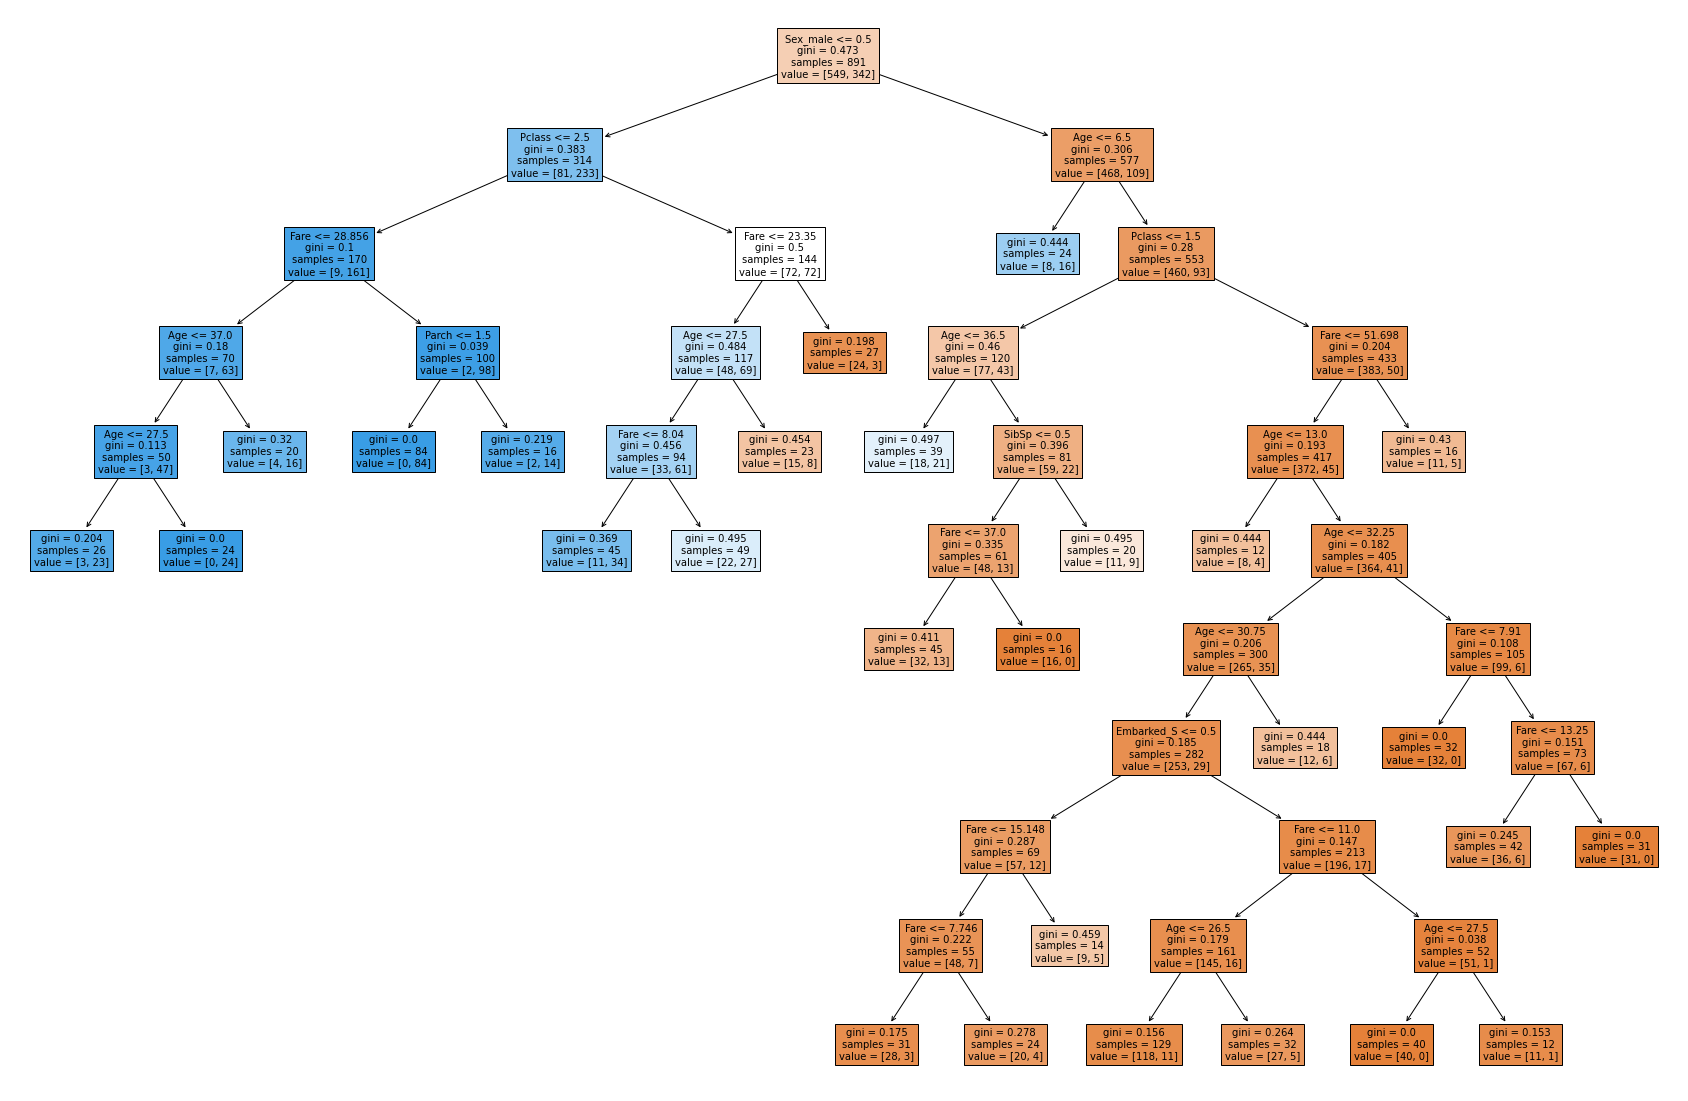

In [37]:
kfold=StratifiedKFold(n_splits=5,shuffle=True,random_state=2022)
clf=DecisionTreeClassifier(random_state=2022)
params={'max_depth':[3,5,10,None],
        'min_samples_split':[2,5,10,50],
        'min_samples_leaf':[1,5,10,50]}
gcvdtc=GridSearchCV(clf, param_grid=params,scoring='roc_auc',cv=kfold)

gcvdtc.fit(X,y)

print(gcvdtc.best_params_)
print(gcvdtc.best_score_)

best_model=gcvdtc.best_estimator_

plt.figure(figsize=(30,20))
tree.plot_tree(best_model,feature_names=X.columns,filled=True,fontsize=10)



## Random Forest Classifier

In [38]:
kfold=StratifiedKFold(n_splits=5,shuffle=True,random_state=2022)
rfc=RandomForestClassifier(random_state=2022)
params={'max_features':[2,3,4,5,6]}
gcvfinal=GridSearchCV(rfc, param_grid=params,scoring='roc_auc',cv=kfold)
gcvfinal.fit(X,y)
print(gcvfinal.best_params_)
print(gcvfinal.best_score_)


{'max_features': 4}
0.8685463589649517


### Conclusion:- From all above algorithms it is clear that Random Forest Algorthim gives us best roc auc result 

# Testing

In [39]:
"""load test dataset"""
df_test = pd.read_csv("/kaggle/input/titanic/test.csv")
df_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [40]:
df_test.drop("Cabin",axis=1,inplace=True)
df_test

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,S
...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,S


In [41]:
df_test.isna().sum()

PassengerId     0
Pclass          0
Name            0
Sex             0
Age            86
SibSp           0
Parch           0
Ticket          0
Fare            1
Embarked        0
dtype: int64

In [42]:
"""Handle Missing Values from test data"""
df_test["Age"] = df_test[["Age","Pclass"]].apply(AgeImputation,axis=1)
df_test["Fare"] = df_test["Fare"].fillna(df_test["Fare"].mean())

In [43]:
df_test.drop(columns=["PassengerId","Name","Ticket"],inplace=True)

In [44]:
dum=pd.get_dummies(df_test,drop_first=True)
dum

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,34.50,0,0,7.8292,1,1,0
1,3,47.00,1,0,7.0000,0,0,1
2,2,62.00,0,0,9.6875,1,1,0
3,3,27.00,0,0,8.6625,1,0,1
4,3,22.00,1,1,12.2875,0,0,1
...,...,...,...,...,...,...,...,...
413,3,25.14,0,0,8.0500,1,0,1
414,1,39.00,0,0,108.9000,0,0,0
415,3,38.50,0,0,7.2500,1,0,1
416,3,25.14,0,0,8.0500,1,0,1


In [45]:
# prediction on test data
test_pred =gcvfinal.predict(dum)
test_pred

array([0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,

# Submission


In [46]:
"""Submission"""
submit=pd.read_csv("../input/titanic/gender_submission.csv")
submit['Survived']=test_pred


#To convert it into CSV
submit.to_csv('./rfr.csv',index=False)

### Conclusion :- More accuray is found in predictions  using KNN and Logisticregression